#### Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

#### Load Dataset

In [3]:
data = pd.read_csv("housing.csv")
data.head

<bound method NDFrame.head of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  ho

#### Explore Data

In [4]:
data.shape

(20640, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [1]:
data.describe()

NameError: name 'data' is not defined

#### Check for Missing Values

In [6]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
data.dropna(subset=['total_bedrooms'], inplace=True)

#### Prepare Features and Split Data

In [9]:
X = pd.get_dummies(data.drop(columns=['median_house_value']), columns=['ocean_proximity'])
y = data['median_house_value']

In [10]:
X = X.dropna()
y = y[X.index]

In [ ]:
# 80% training, 20% testing — random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#### Linear Regression (Baseline Model)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

In [13]:
print("R2:   %.2f" % r2_score(y_test, y_hat))
print("RMSE: %.2f" % np.sqrt(mean_squared_error(y_test, y_hat)))

R2:   0.64
RMSE: 68263.41


#### Random Forest Regressor

In [14]:
model = RandomForestRegressor(n_estimators=50, max_depth=8, max_features='sqrt', random_state=42)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_hat = model.predict(X_test)

In [16]:
print("R²:", r2_score(y_test, y_hat))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_hat)))

R²: 0.7229751838163059
RMSE: 59603.512165097236


#### Feature Importance Plot

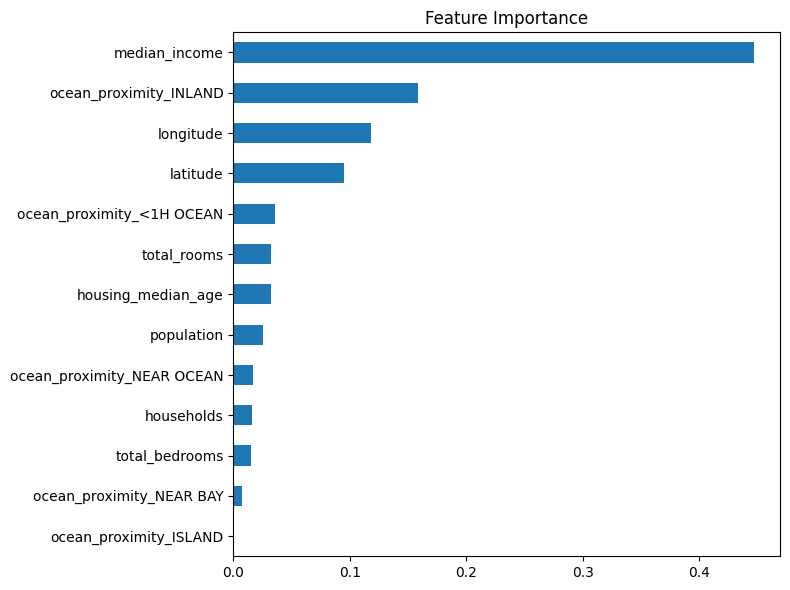

In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()